## Лабораторна робота №2.



Оцінювання даної роботи буде ураховувати якість ваших візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.

Під час виконання вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.






Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою [titanic.csv](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).  
Цей датасет ви вже використовували в лабораторній роботі №1 ;)  
  
  ```NB:побудовані графіки та гістограми мають бути змістовними і візуально зрозумілими.```
  
  
  

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dataset = pd.read_csv("sample_data/train.csv")

**Задача 1:** Який відсоток виживання серед чоловіків / жінок?

In [ ]:
survived_on_titanic_avarage = dataset.groupby("Sex")["Survived"].mean()
survived_on_titanic_percentage = survived_on_titanic_avarage * 100

print(survived_on_titanic_percentage)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


**Задача 2:** Відтворіть ці графіки  
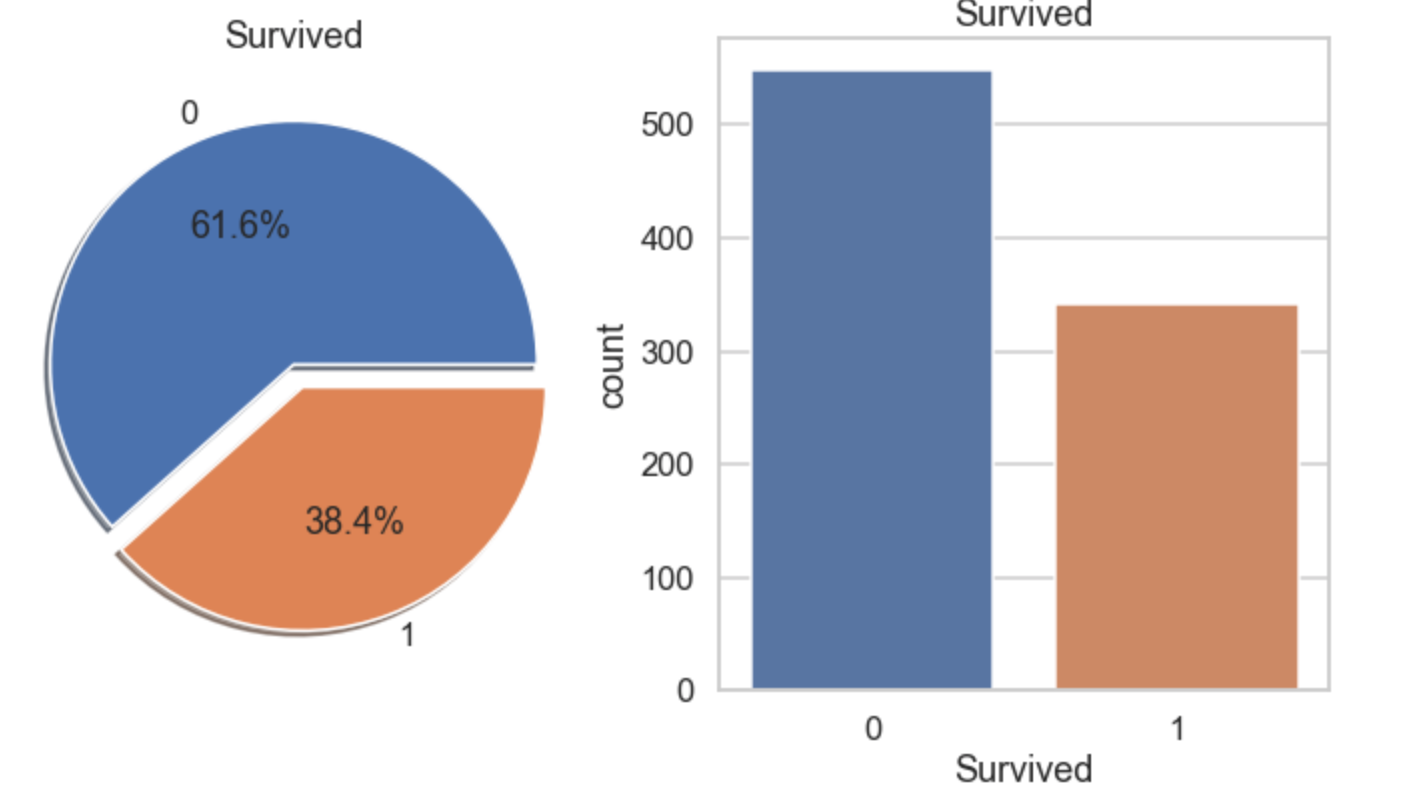


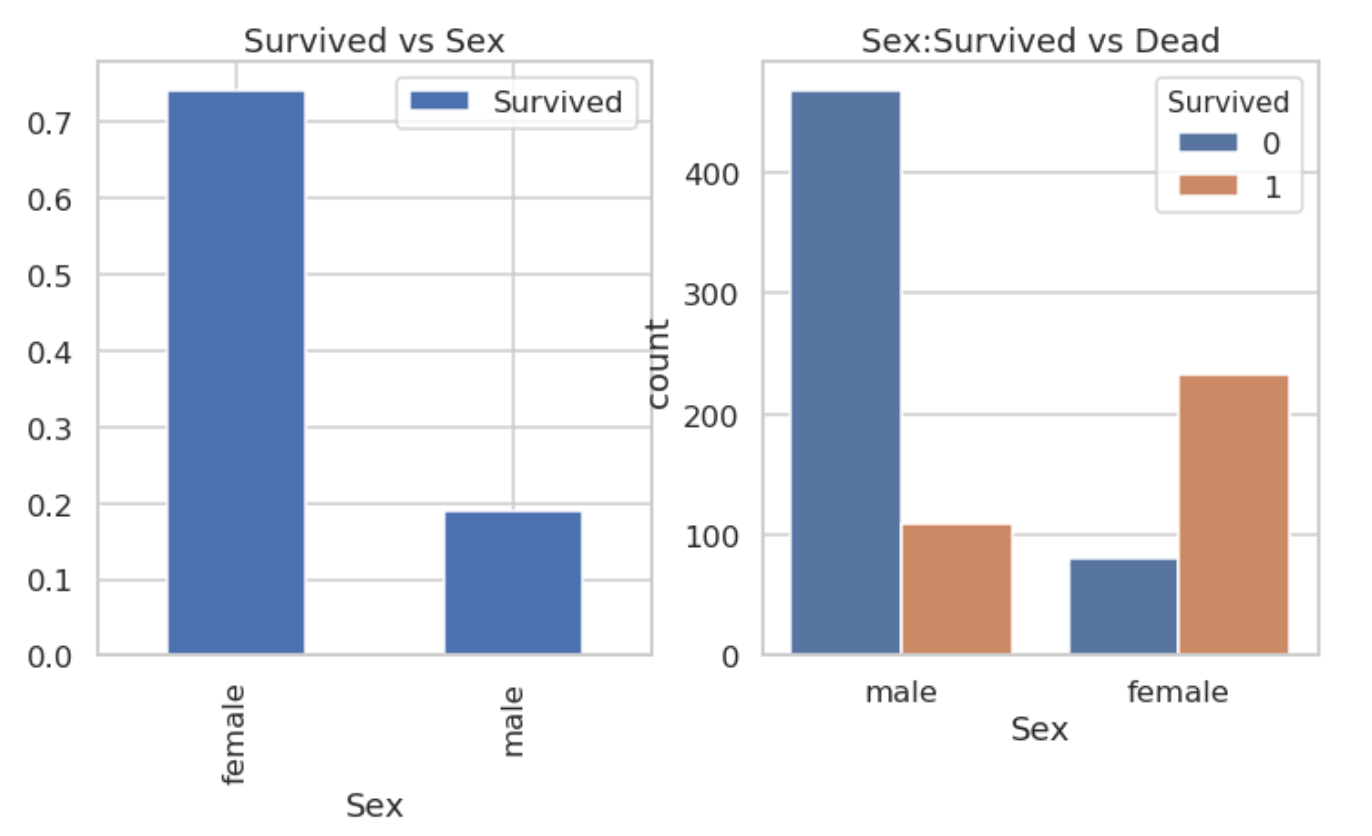

Відсоток людей, котрі не вижили:  38.4
Відсоток людей, котрі не вижили:  61.6


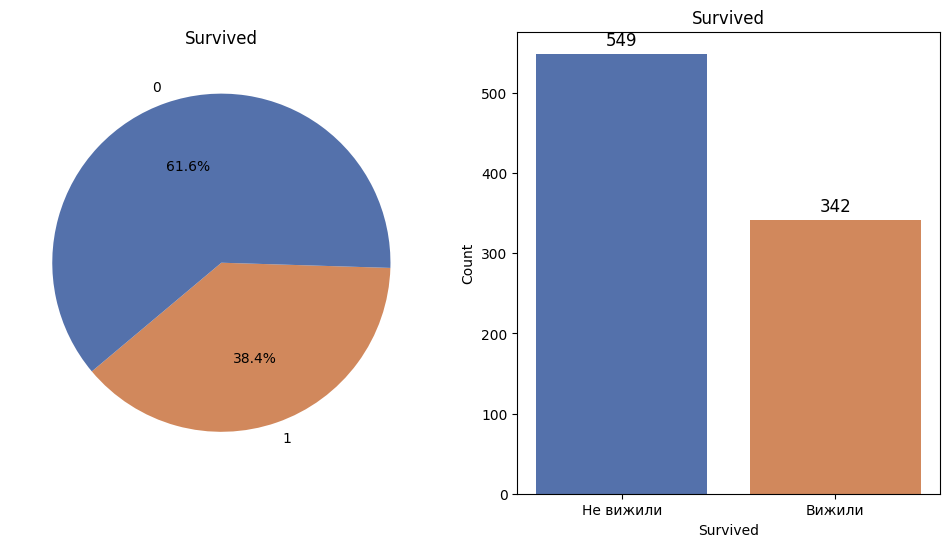

In [ ]:
survived_on_titanic_av = dataset['Survived'].mean()
survived_on_titanic_per = survived_on_titanic_av * 100
survived_on_titanic_per_rounded = round(survived_on_titanic_per, 1)
not_survived_on_titanic_per_rounded = 100.0 - survived_on_titanic_per_rounded

survived = len(dataset[dataset['Survived'] == 1])
notSurvived = len(dataset[dataset['Survived'] == 0])

plt.figure(figsize=(12, 6))

###
labels = ["1", "0"]
sises = [survived_on_titanic_per_rounded, not_survived_on_titanic_per_rounded]
colors = [ "#D1885C", "#5471AB"]

plt.subplot(1, 2, 1)
plt.pie(sises, labels=labels, autopct="%1.1f%%", colors=colors, startangle=220)
plt.title("Survived")
###



###
categories = ["Не вижили", "Вижили"]
counts = [notSurvived, survived]

plt.subplot(1, 2, 2)
plt.bar(categories, counts, color=["#5471AB", "#D1885C"])
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survived")

for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12)
###
plt.show()


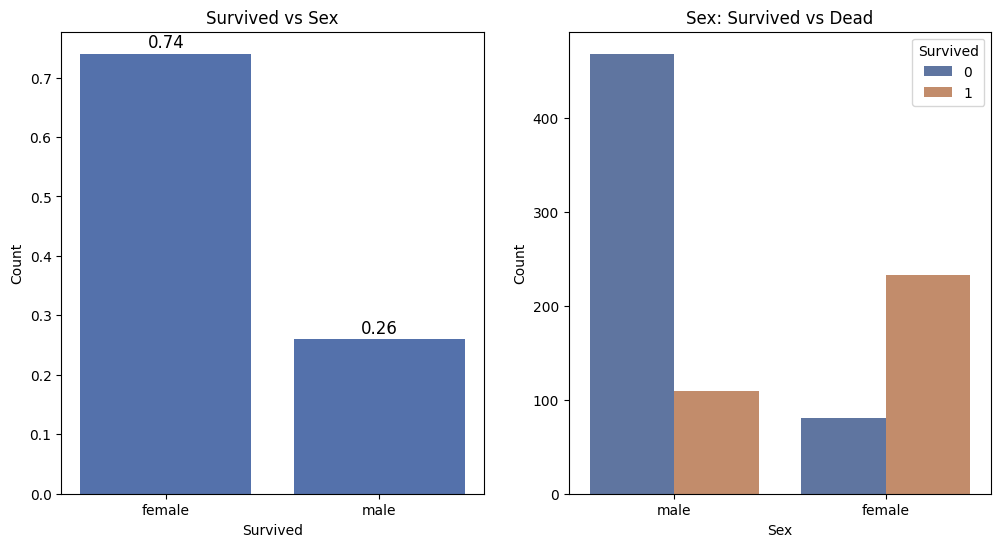

In [ ]:
plt.figure(figsize=(12, 6))

###
plt.subplot(1, 2, 1)
categoriesTask2 = ["female", "male"]
survived_on_titanic_avTask2 = dataset[dataset["Sex"] == "female"]["Survived"].mean()
countsTask2 = [round(survived_on_titanic_avTask2, 2), round(1 - survived_on_titanic_avTask2, 2)]
plt.bar(categoriesTask2, countsTask2, color=["#5471AB", "#5471AB"])
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survived vs Sex")

for i, count in enumerate(countsTask2):
    plt.text(i, count + 0.01, str(count), ha='center', fontsize=12)
###


###
plt.subplot(1, 2, 2)
sns.countplot(x="Sex", hue="Survived", data=dataset, palette=["#5471AB", "#D1885C"])

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Sex: Survived vs Dead")
plt.legend(title="Survived", labels=["0", "1"])
plt.show()

###


plt.show()

The number of males on board was much higher than the number of females, but in percentage, more females were saved, while fewer males managed to survive.

**Задача 3:** Скільки пропущених значень в датасеті по кожній із змінних?

In [ ]:
#code
print("Number of all null varibles in column [PassengerId] : ", dataset["PassengerId"].isna().sum())
print("Number of all null varibles in column [Survived] : ", dataset["Survived"].isna().sum())
print("Number of all null varibles in column [Pclass] : ", dataset["Pclass"].isna().sum())
print("Number of all null varibles in column [Name] : ", dataset["Name"].isna().sum())
print("Number of all null varibles in column [Sex] : ", dataset["Sex"].isna().sum())
print("Number of all null varibles in column [Age] : ", dataset["Age"].isna().sum())
print("Number of all null varibles in column [SibSp] : ", dataset["SibSp"].isna().sum())
print("Number of all null varibles in column [Parch] : ", dataset["Parch"].isna().sum())
print("Number of all null varibles in column [Ticket] : ", dataset["Ticket"].isna().sum())
print("Number of all null varibles in column [Fare] : ", dataset["Fare"].isna().sum())


Number of all null varibles in column [PassengerId] :  0
Number of all null varibles in column [Survived] :  0
Number of all null varibles in column [Pclass] :  0
Number of all null varibles in column [Name] :  0
Number of all null varibles in column [Sex] :  0
Number of all null varibles in column [Age] :  177
Number of all null varibles in column [SibSp] :  0
Number of all null varibles in column [Parch] :  0
Number of all null varibles in column [Ticket] :  0
Number of all null varibles in column [Fare] :  0


**Задача 4:** Назвіть найпопулярніше **жіноче** ім'я на кораблі.

In [ ]:
#code
allFemales = dataset[dataset["Sex"] == "female"]

name_brackets = allFemales["Name"].str.extract(r"\((\w+)")[0]

name_titles = allFemales["Name"].str.extract(r"(?:Mrs\.|Miss\.|Ms\.)\s+(\w+)")[0]

names = name_brackets.fillna(name_titles)

most_common_name = names.value_counts().idxmax()
# most_common_name = names.value_counts().head(3)

print(most_common_name)


0
Anna         15
Mary         14
Elizabeth    11
Name: count, dtype: int64


**Задача 5:** Назвіть найпопулярніше **чоловіче** ім'я на кораблі.

In [ ]:
#code
allMales = dataset[dataset["Sex"] == "male"]

male_name_title = allMales["Name"].str.extract(r"(?:Mr\.|Master\.|Rev\.)\s*(\S+)")[0]

most_common_name_male = male_name_title.value_counts().idxmax()

print(most_common_name_male)

William


**Задача 6:** Побудуйте діаграми співвідношення загиблих та виживших за інформацією про те, квитки якого класу були у пасажирів.
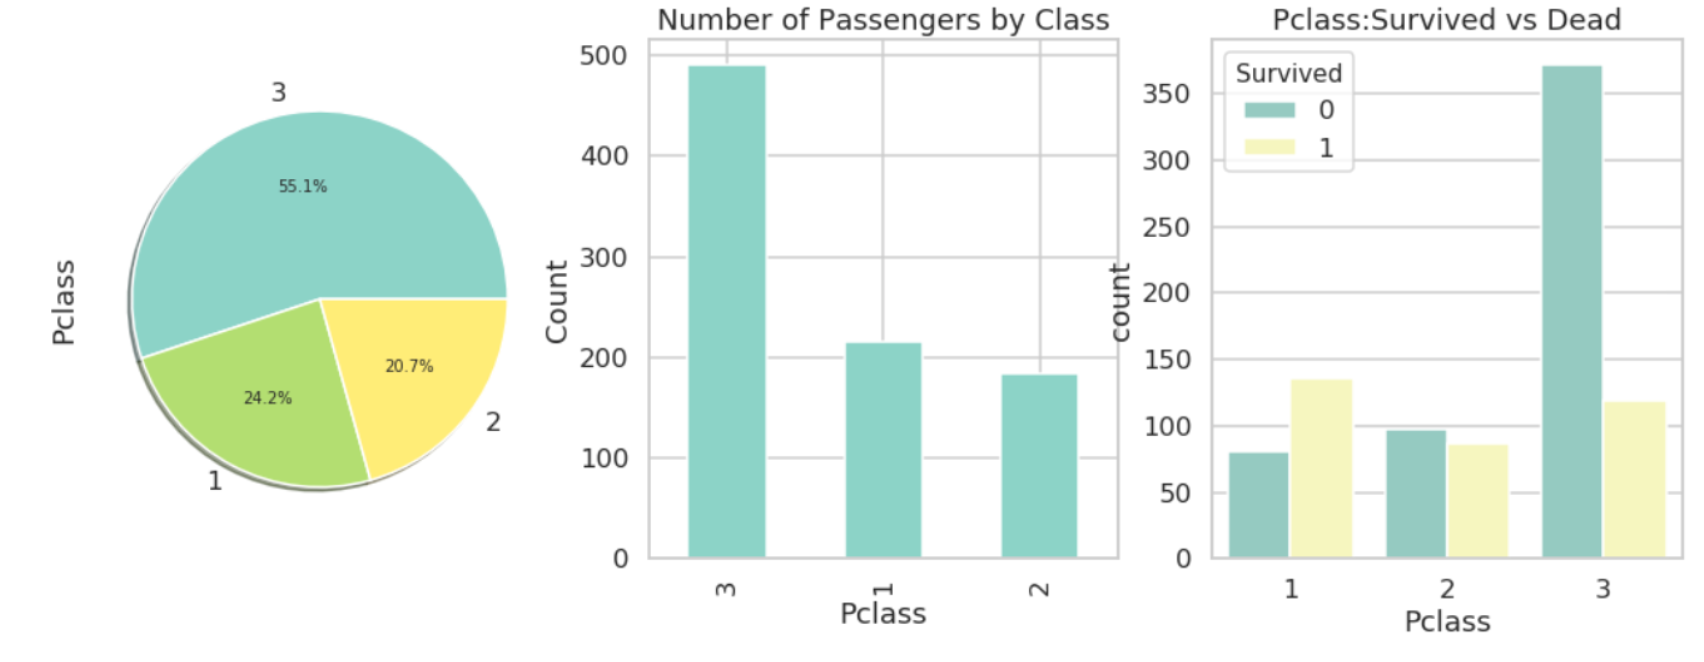

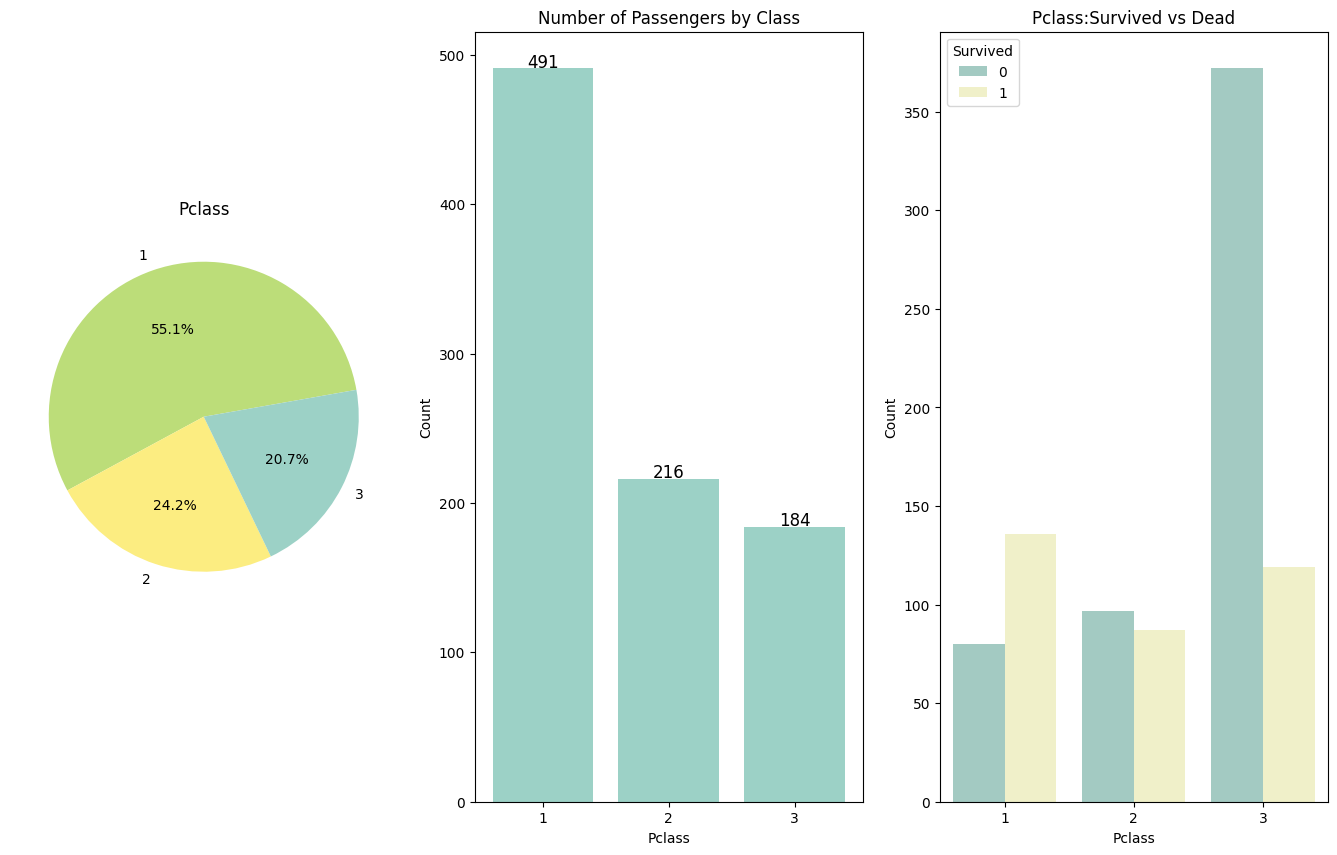

In [ ]:
#code
class_percentage = dataset['Pclass'].value_counts(normalize=True) * 100

plt.figure(figsize=(17, 10))

###
labels6 = ["1", "2", "3"]
sises6 = class_percentage.tolist()
colors6 = [ "#BCDD79", "#FCED81", "#9CD1C6"]

plt.subplot(1, 3, 1)
plt.pie(sises6, labels=labels6, autopct="%1.1f%%", colors=colors6, startangle=10)
plt.title("Pclass")
###


###
plt.subplot(1, 3, 2)
class_count = dataset['Pclass'].value_counts()
categoriesTask6 = ["1", "2", "3"]

countsTask6 = class_count.to_list()
plt.bar(categoriesTask6, countsTask6, color=["#9CD1C6"])
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Number of Passengers by Class")

for i, count in enumerate(countsTask6):
    plt.text(i, count + 1, str(count), ha='center', fontsize=12)
###


###
plt.subplot(1, 3, 3)
sns.countplot(x="Pclass", hue="Survived", data=dataset, palette=["#9CD1C6", "#F6F6C2"])

plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Pclass:Survived vs Dead")
plt.legend(title="Survived", labels=["0", "1"])
###

Прокоментуйте побудовані графіки

On the first diagram, we can see that the most popular class among passengers is the first one, with 419 people on board. On the last one, we can clearly see that the lowest death rate is in the first class, while the highest death rate is in the third class.

**Задача 7:** Побудуйте наступні графіки та опишіть, що власне на них відображається.  
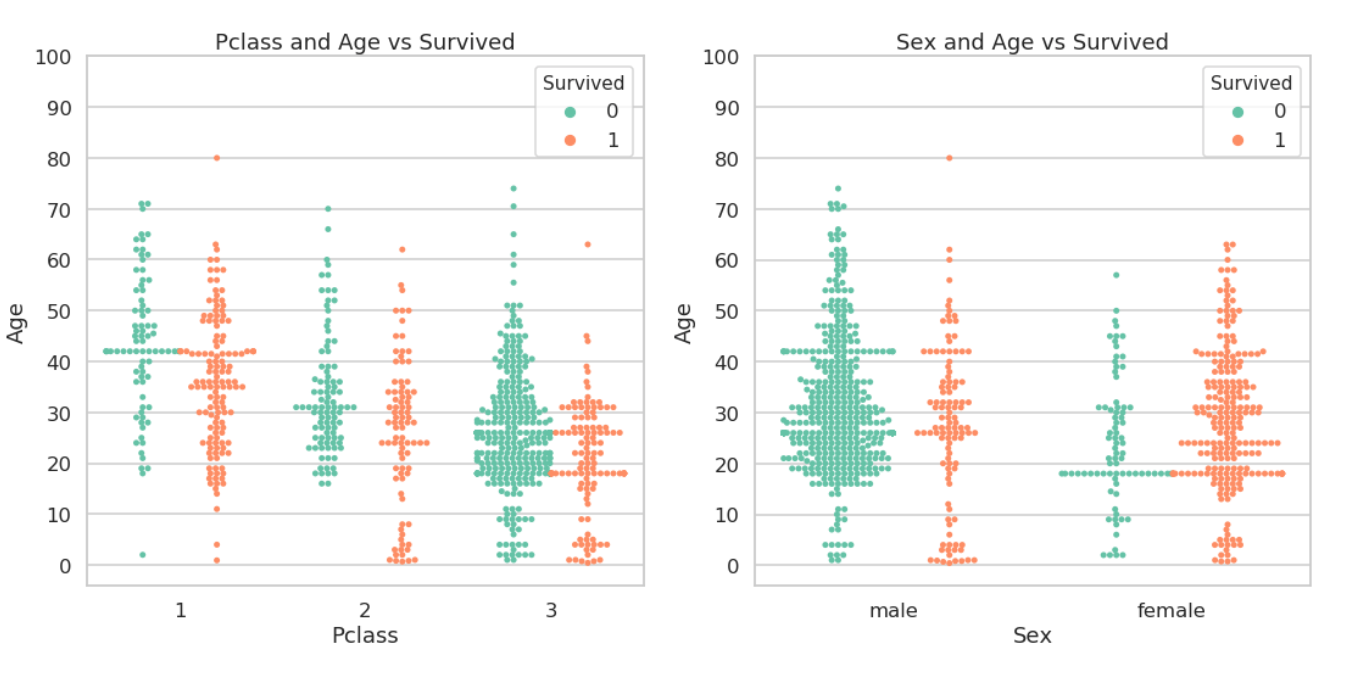![image.png](attachment:51486806-bd5d-4ae3-b95a-548aebf83de2.png)

Text(0.5, 1.0, 'Sex and Age vs Survived')

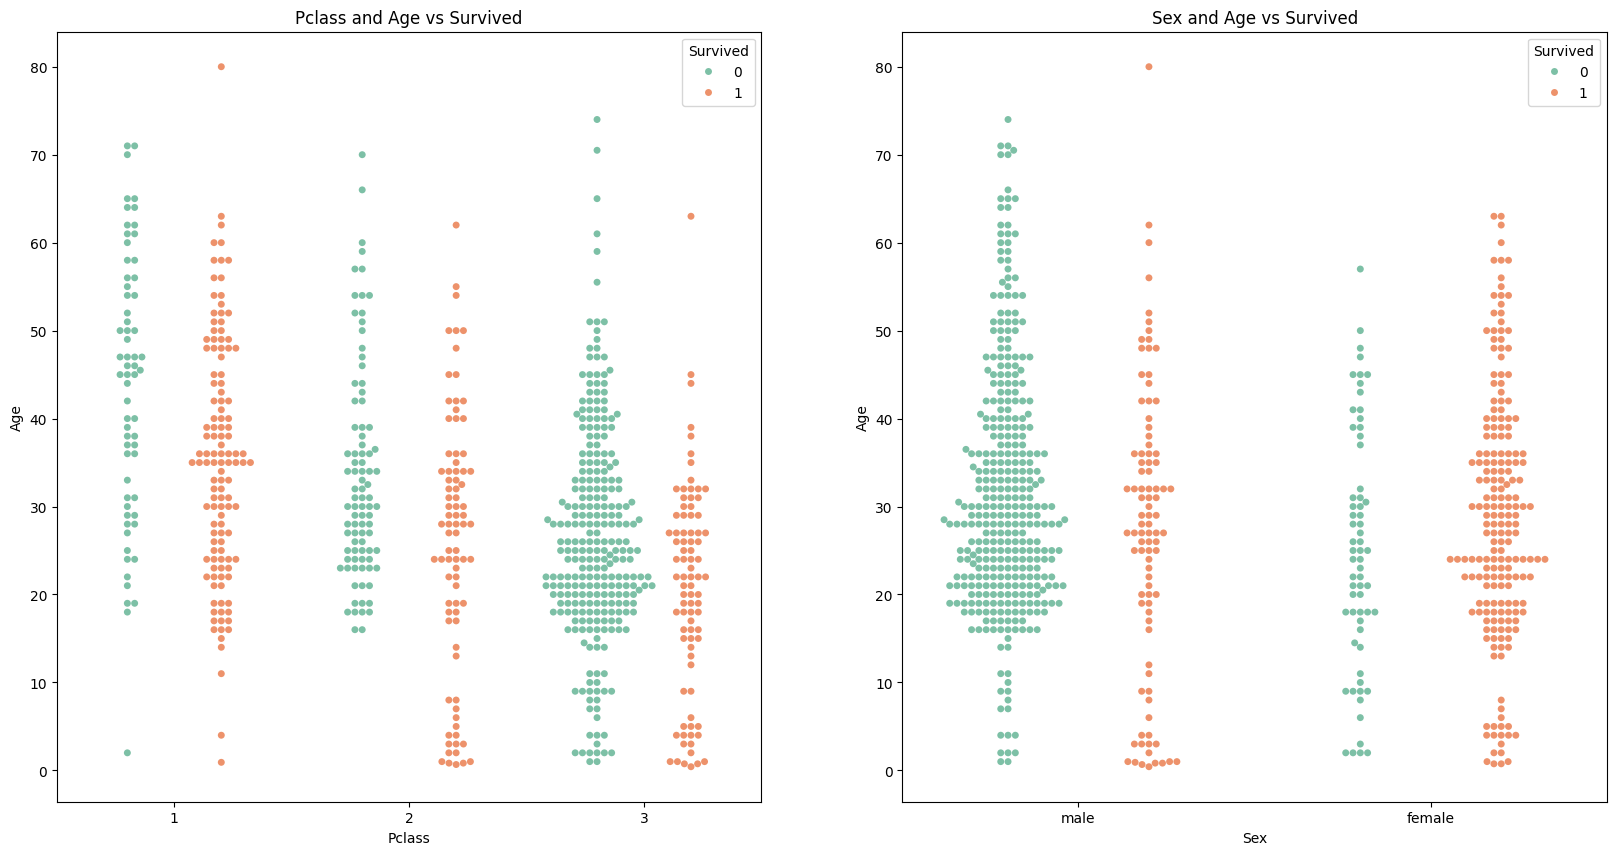

In [8]:
#code
plt.figure(figsize=(20, 10))

###
plt.subplot(1, 2, 1)
sns.swarmplot(
    data=dataset,
    x="Pclass",
    y="Age",
    hue="Survived",
    palette={0: "#7DC0A6", 1: "#ED926B"},
    dodge=True
)
plt.title("Pclass and Age vs Survived")
###


###
plt.subplot(1, 2, 2)
sns.swarmplot(
    data=dataset,
    x="Sex",
    y="Age",
    hue="Survived",
    palette={0: "#7DC0A6", 1: "#ED926B"},
    dodge=True
)
plt.title("Sex and Age vs Survived")
###

Прокоментуйте побудовані графіки

From the first graph, it can be understood that most of the dead were in the 20-35 age group, mostly in the third class, also the mortality rate increases as the class falls. It is also noticeable that many 2nd and 3rd grade children were saved, in the second graph, it can be seen that the greatest mortality is among men in the 18-45 age group, and more women survived in the 15 to 40 year group

**Задача 8** Побудуйте наступні діаграми розподілів:  

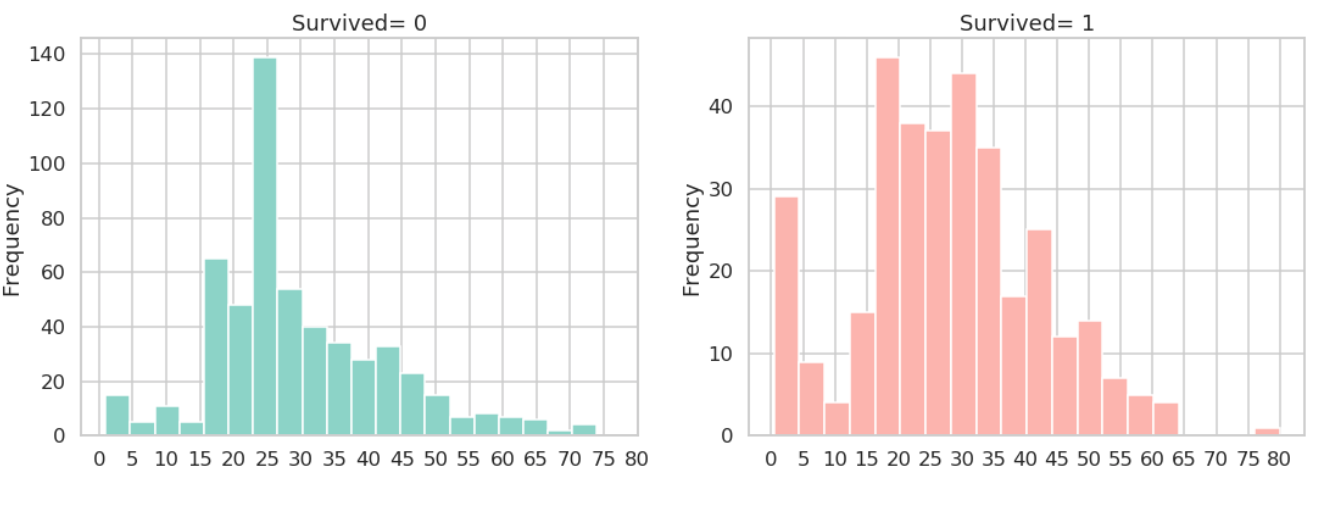



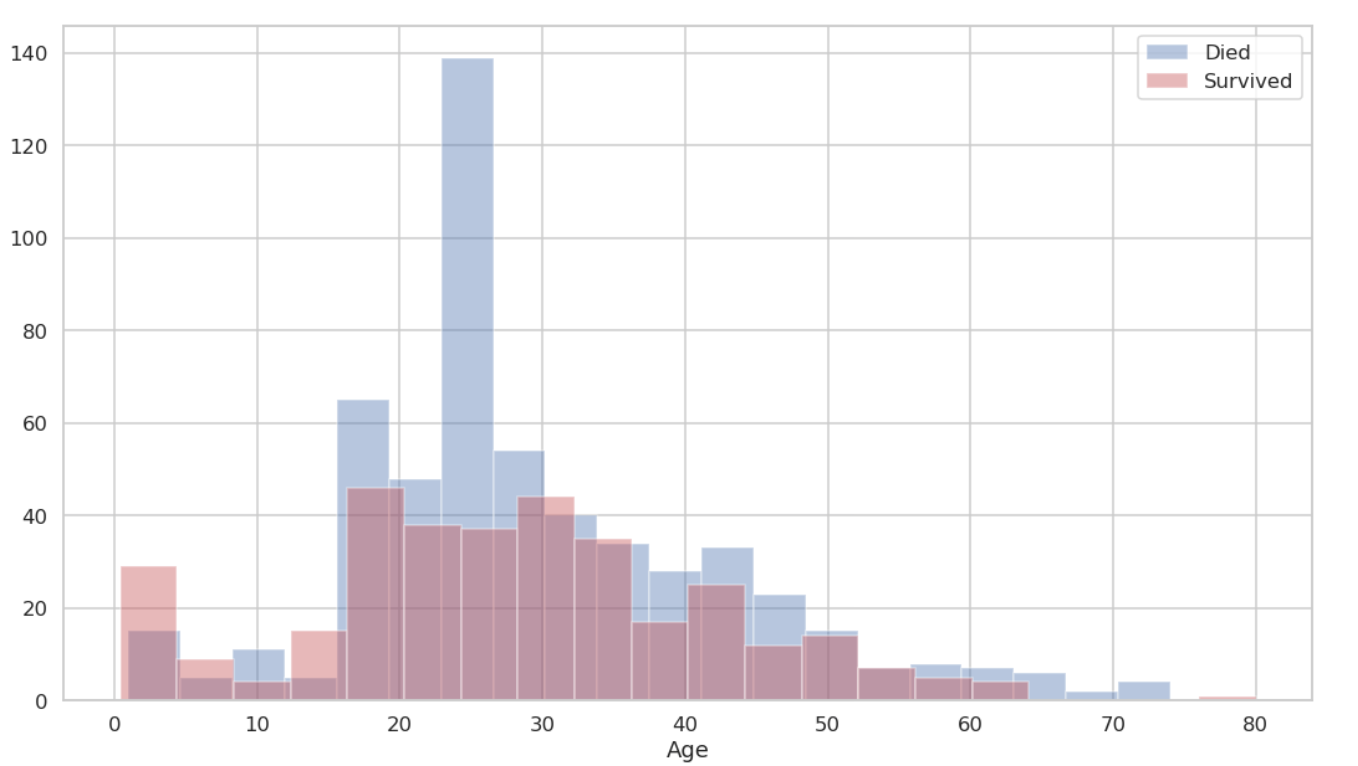

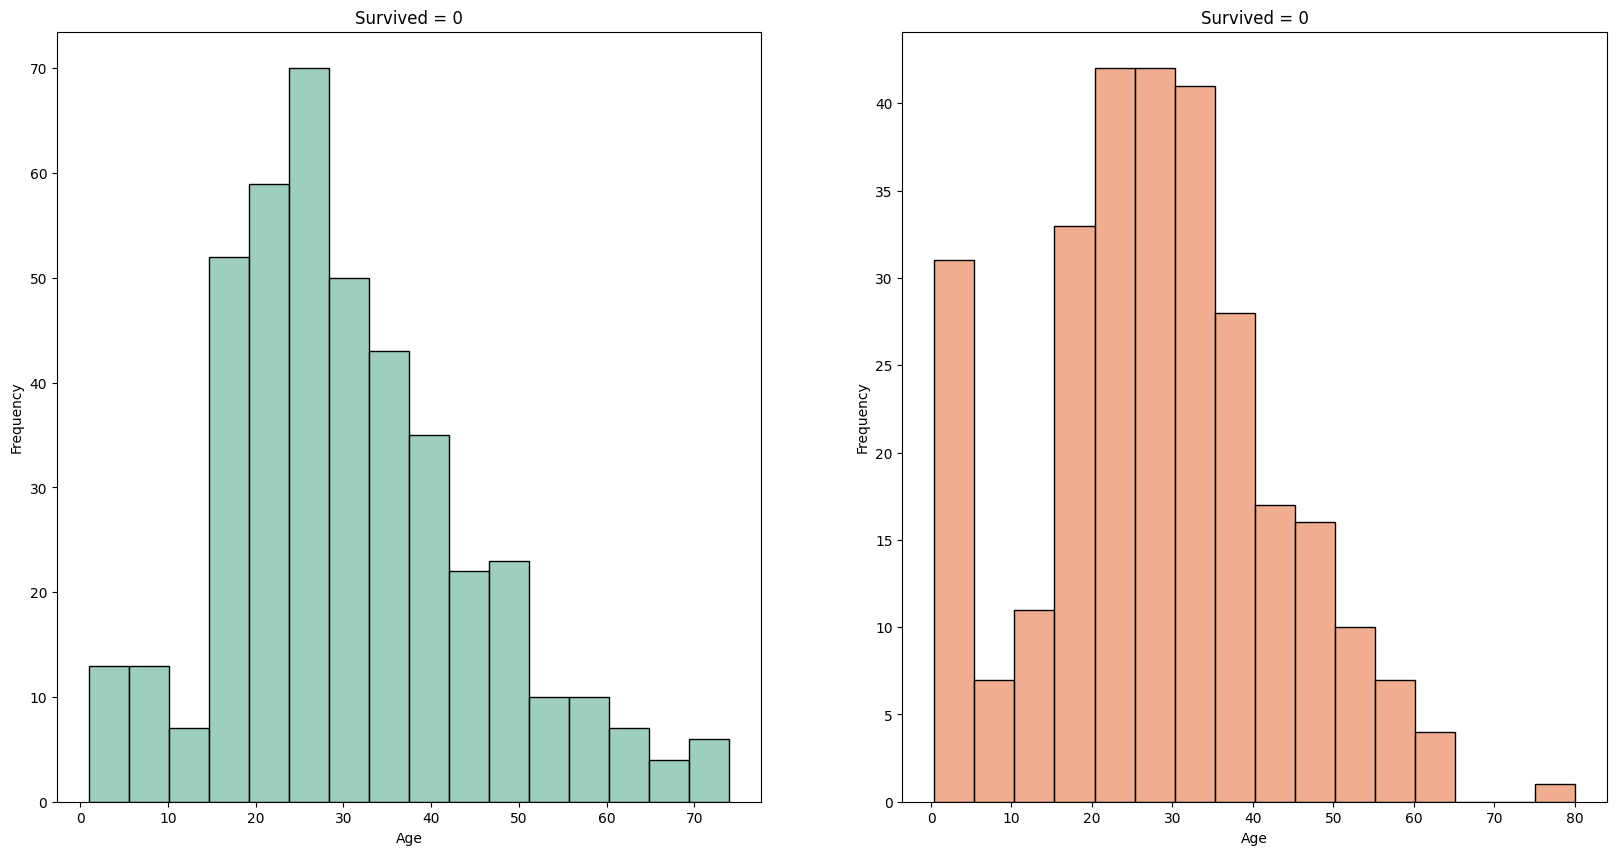

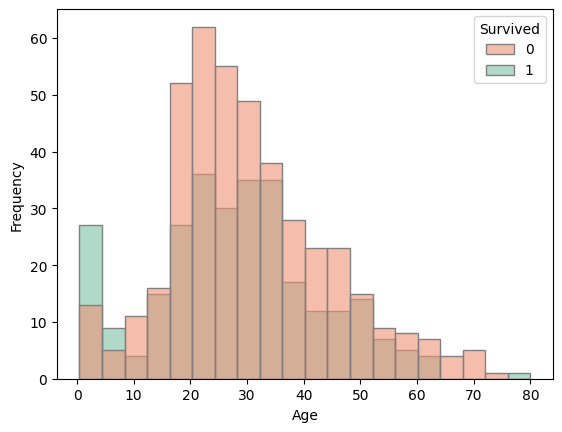

In [32]:
#code
plt.figure(figsize=(20, 10))
###
plt.subplot(1, 2, 1)
dead = dataset[dataset["Survived"] == 0]

sns.histplot(
    data=dead,
    x="Age",
    color="#7DC0A6",
)

plt.title("Survived = 0")
plt.xlabel("Age")
plt.ylabel("Frequency")
###


###
plt.subplot(1, 2, 2)
surv = dataset[dataset["Survived"] == 1]

sns.histplot(
    data=surv,
    x="Age",
    color="#ED926B",
)

plt.title("Survived = 1")
plt.xlabel("Age")
plt.ylabel("Frequency")

###

plt.show()


sns.histplot(
    data=dataset,
    x="Age",
    hue="Survived",
    multiple="layer",
    palette={0: "#ED9275", 1: "#7DC0A6"},
    alpha=0.6,
    edgecolor="grey"
)

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Що можна сказати, про розподіли змінних згідно до цих гістограм? Чи достатньо лише побудованих візуалізацій для висновків щодо розподілів та статистичних оцінок?

It can be said that the age of death and survivors is +- the same. For a superficial analysis of the graphs, it is quite enough, if you need to dive deeper, then you need more statistics

**Задача 9:** Побудуйте наступні діаграми та проведіть аналітику шансів на виживання серед пасажирів:  
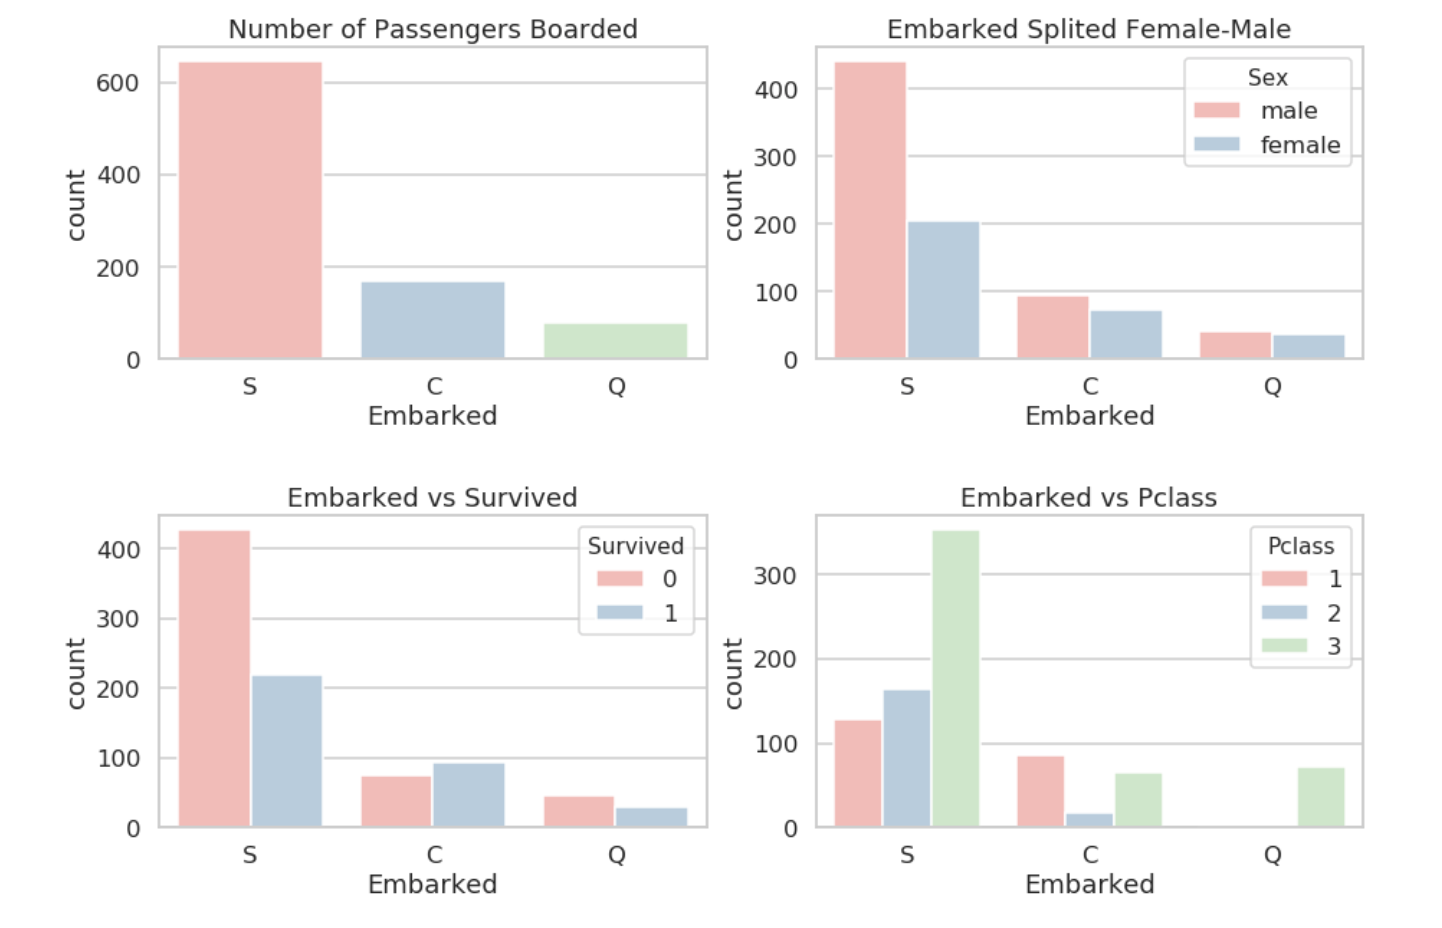

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


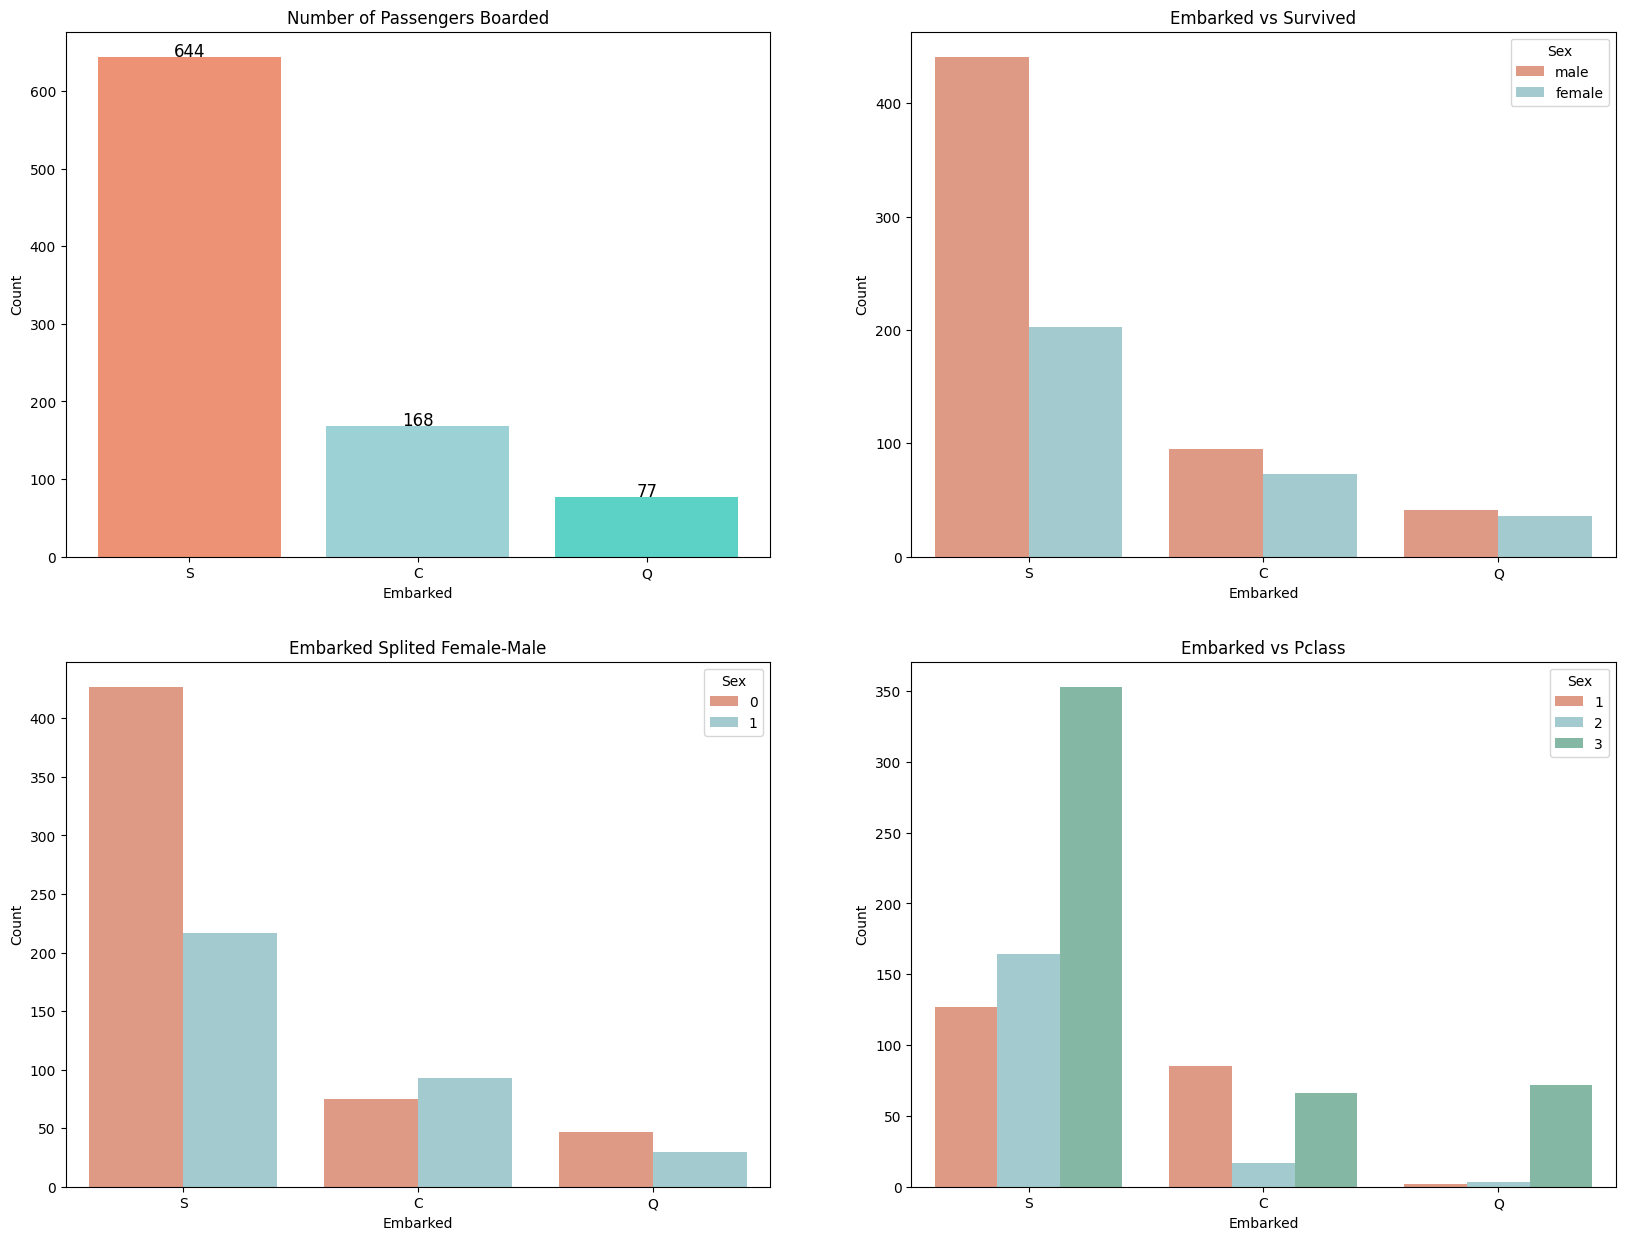

In [58]:
#code
plt.figure(figsize=(20, 15))

###
plt.subplot(2, 2, 1)
em_count = dataset['Embarked'].value_counts()
print(em_count)
categoriesTask9 = ["S", "C", "Q"]

countsTask9 = em_count.to_list()
plt.bar(categoriesTask9, countsTask9, color=["#ED9275", "#9CD1D6", "#5CD1C6"])
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Number of Passengers Boarded")

for i, count in enumerate(countsTask9):
    plt.text(i, count + 1, str(count), ha='center', fontsize=12)
###



###
plt.subplot(2, 2, 2)
sns.countplot(x="Embarked", hue="Sex", data=dataset, palette=["#ED9275", "#9CD1D6"])

plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Embarked vs Survived")
plt.legend(title="Survived", labels=["male", "female"])
###


###
plt.subplot(2, 2, 3)
sns.countplot(x="Embarked", hue="Survived", data=dataset, palette=["#ED9275", "#9CD1D6"])

plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Embarked Splited Female-Male")
plt.legend(title="Sex", labels=["0", "1"])
###


###
plt.subplot(2, 2, 4)
sns.countplot(x="Embarked", hue="Pclass", data=dataset, palette=["#ED9275", "#9CD1D6", "#7DC0A6"])

plt.xlabel("Embarked")
plt.ylabel("Count")
plt.title("Embarked vs Pclass")
plt.legend(title="Class", labels=["1", "2", "3"])
###

Most of the passengers were at Southampton, and there was the highest death rate, but also the highest number of survivors, so the best chance of survival was in third class according to fourth graph


***Завдача 10** Побудуйте діаграму розподілу ```вартості квитка``` відповідно до якого классу належіть пасажир.

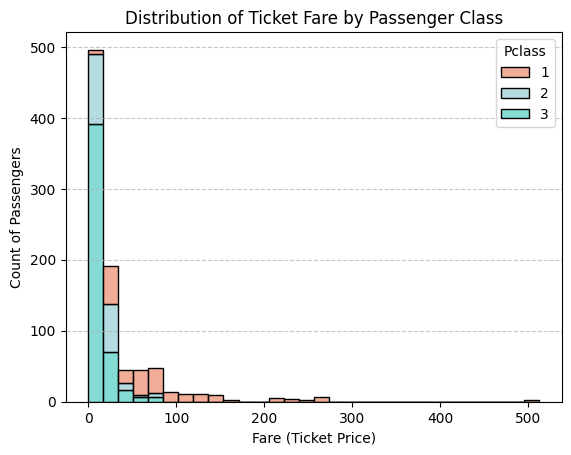

In [72]:
#code
sns.histplot(
    data=dataset,
    x="Fare",
    hue="Pclass",
    bins=30,
    multiple="stack",
    palette=["#ED9275", "#9CD1D6", "#5CD1C6"],
    edgecolor="black"
)

plt.xlabel("Fare (Ticket Price)")
plt.ylabel("Count of Passengers")
plt.title("Distribution of Ticket Fare by Passenger Class")

plt.grid(axis="y", linestyle="--", alpha=0.7)


Прокоментуйте побудовані графіки

якщо fare це вартісь квитка, то 3 клас в середньому коштує 10 умовних одиниць, 2 клас 20-50, третій від 50 до 250
